# Data Profiling & Exploratory Data Analysis (EDA)

Notebook ini bertujuan untuk melakukan penapisan awal, melihat distribusi dataset ulasan Shopee (toko Forebie), dan memvisualisasikan insight sebelum masuk ke tahap pemodelan klasifikasi sentimen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualisasi style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Dataset

In [2]:
# Load dataset yang sudah diekstrak fiturnya
df = pd.read_csv("../data/processed/dataset_fitur.csv")

# Menampilkan 5 data pertama
df.head()

## 2. Data Profiling

In [3]:
# Info dataset
df.info()

,id_komentar,produk_url,username,rating,ulasan,nama_produk,jumlah_kata,panjang_karakter,label_sentimen
0,80408477470,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,"Produk: Barang rusak | Sorry to say, perdana g...",FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,99,549,Negatif
1,16989422782,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,pertama kali make forebie beruntusan&jerawat m...,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,75,459,Negatif
2,17285726857,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,"Mungkin setiap org cok""kan,di aku ga ccok pana...",FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,33,214,Negatif
3,29322971421,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,kaget banget baru semingguan pakai langsung bi...,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,52,319,Negatif
4,15251941065,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,"bekas jerawat pie malah jadi bopeng 😢, bopeng ...",FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,25,140,Negatif


In [4]:
# Pengecekan Missing Values
df.isnull().sum()

id_komentar         0
produk_url          0
username            7
rating              0
ulasan              0
nama_produk         0
jumlah_kata         0
panjang_karakter    0
label_sentimen      0
dtype: int64

In [5]:
# Statistik Deskriptif untuk data numerik
df.describe()

,id_komentar,rating,jumlah_kata,panjang_karakter
count,6.730000e+02,673.000000,673.00000,673.000000
mean,4.453378e+10,3.655275,33.20951,200.726597
std,2.986310e+10,1.272432,28.59876,171.167028
min,1.050760e+10,1.000000,2.00000,11.000000
25%,1.689931e+10,3.000000,13.00000,79.000000
50%,3.300195e+10,4.000000,26.00000,155.000000
75%,7.783059e+10,5.000000,43.00000,259.000000
max,1.005041e+11,5.000000,238.00000,1496.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Sentimen
Melihat bagaimana persebaran kelas target (Positif, Netral, Negatif).

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7828\2979564858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


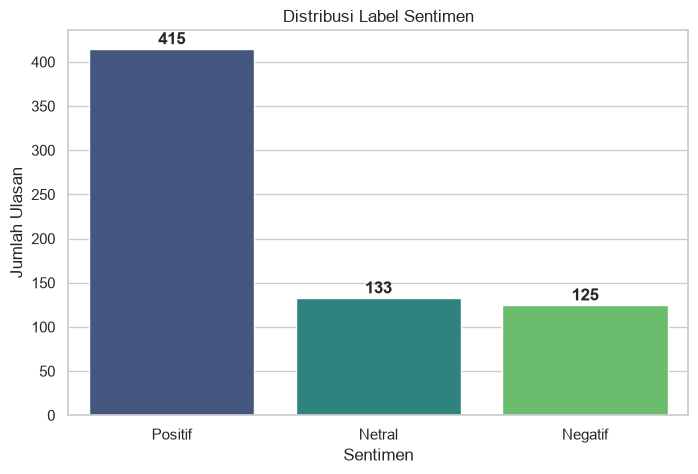

In [6]:
sentiment_counts = df['label_sentimen'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

### 3.2 Distribusi Jumlah Kata & Deteksi Outlier (Boxplot)
Visualisasi distribusi jumlah kata pada ulasan menggunakan Histogram dan Boxplot.

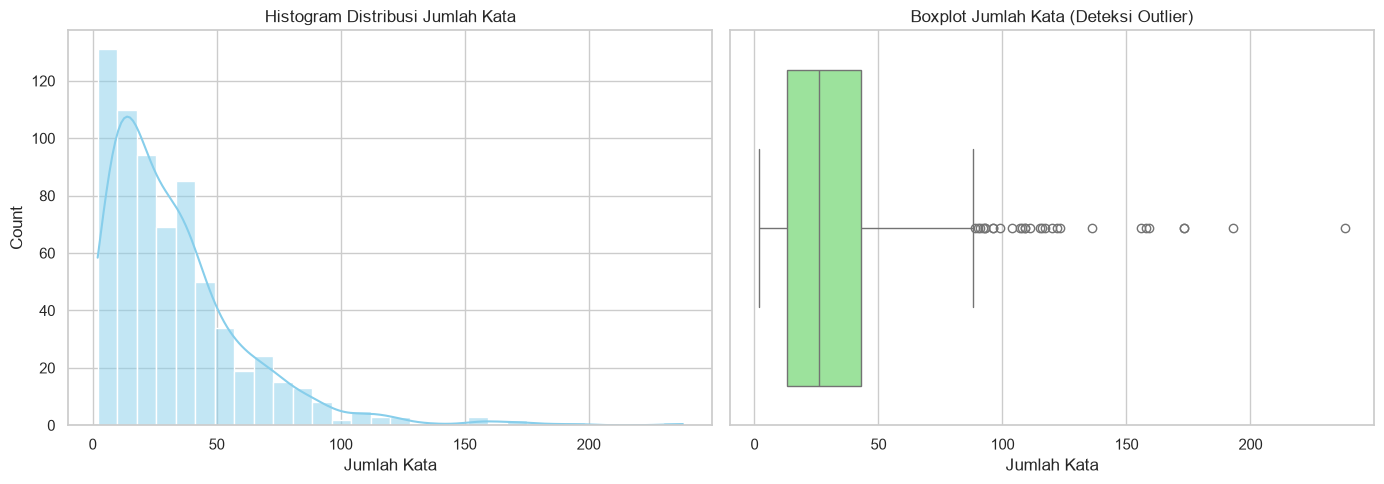

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['jumlah_kata'], bins=30, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Histogram Distribusi Jumlah Kata")
axes[0].set_xlabel("Jumlah Kata")

sns.boxplot(x=df['jumlah_kata'], color="lightgreen", ax=axes[1])
axes[1].set_title("Boxplot Jumlah Kata (Deteksi Outlier)")
axes[1].set_xlabel("Jumlah Kata")

plt.tight_layout()
plt.show()

### 3.3 Matriks Korelasi (Heatmap)
Melihat hubungan antara variabel numerik: `rating`, `jumlah_kata`, dan `panjang_karakter`.

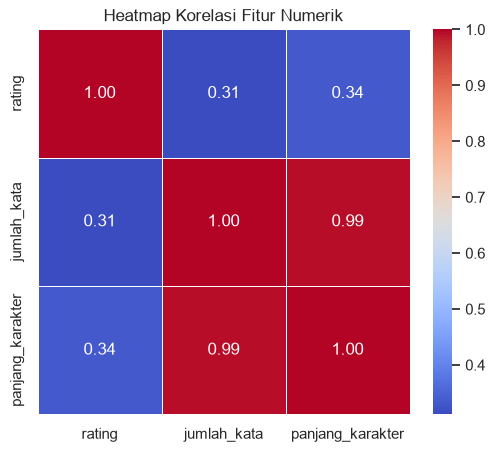

In [8]:
numeric_df = df[['rating', 'jumlah_kata', 'panjang_karakter']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

### 3.4 Distribusi Ulasan Berdasarkan Nama Produk
Melihat produk mana yang paling banyak menerima ulasan dalam dataset ini.

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7828\1544741538.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts.values, y=product_counts.index, palette="magma")


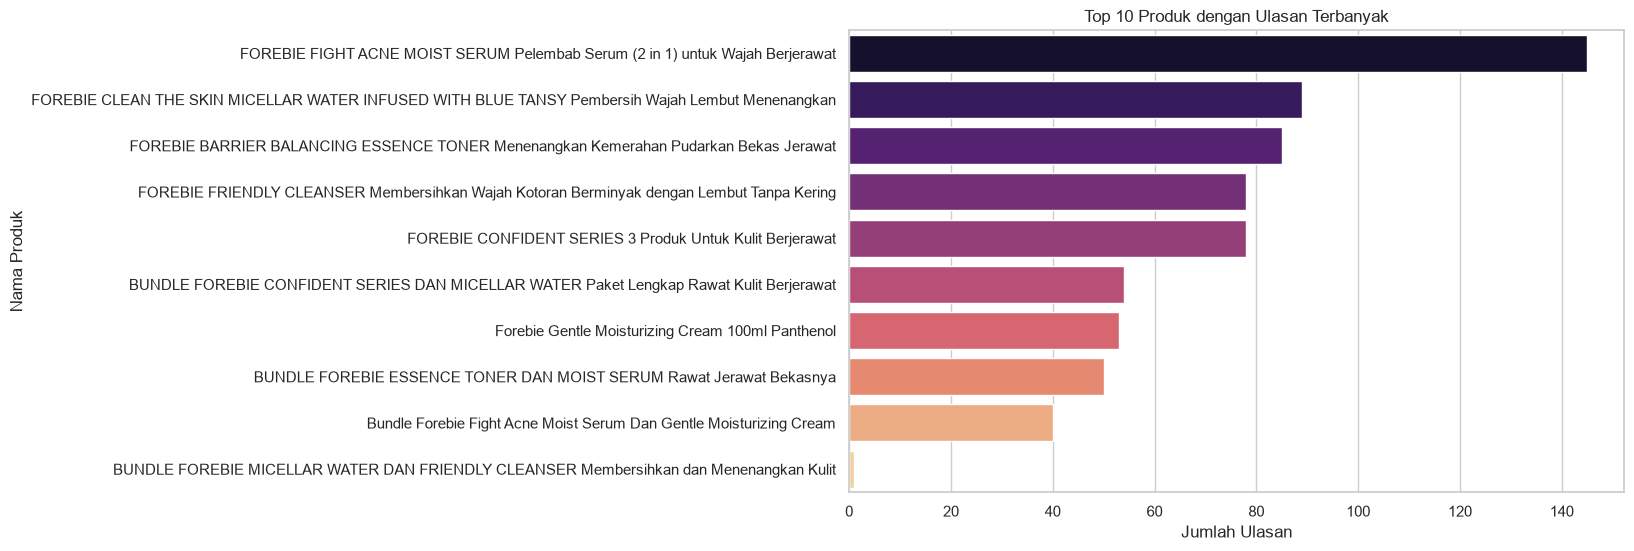

In [9]:
product_counts = df['nama_produk'].value_counts().head(10) # Ambil Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, palette="magma")
plt.title("Top 10 Produk dengan Ulasan Terbanyak")
plt.xlabel("Jumlah Ulasan")
plt.ylabel("Nama Produk")
plt.show()